<div style="background-color:#f8f9fa;
    padding:20px;
    border:2px solid #360084;
    border-radius:8px;
    margin:10px 0;">
    <div style="background-color:#fafdf0;
        line-height:2;
        text-align:center;
        border:2px solid #360084;
        padding:15px;
        border-radius:5px;">
        <div style="color:#008B8B;
            font-size:24pt;
            font-weight:700;">
            Linear Regression Residual Diagnosis: Non-constant variance (Heterskedasticity)
        </div>
    </div> 
    <div style="margin-top:15px; padding:10px;">
        <strong>Course:</strong> Econometrics<br>
        <strong>Topic:</strong> Linear Regression Residual Analysis<br>
        <strong>Instructor:</strong> Dr. Saad Laouadi<br>
        <strong>Objective:</strong> Generate Synthetic Data for Visualizing Diagnostic Plot Patterns for checking heteroskedasticity
    </div>
</div>

---

In [1]:
# ====================================================== #
#            Environment Setup
# ====================================================== #

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (15, 12)
sns.set_style("whitegrid")

print("*"*52)
print("Environment Setup".center(52))
%reload_ext watermark
%watermark -iv -v -ud -a "Dr. Saad Laouadi"
print("*"*52)

****************************************************
                 Environment Setup                  
Author: Dr. Saad Laouadi

Last updated: 2025-06-15

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.1.0

numpy      : 2.3.0
matplotlib : 3.10.0
scipy      : 1.15.3
statsmodels: 0.14.4
seaborn    : 0.13.2

****************************************************


In [2]:
print("=== SYNTHETIC DATA FOR DIAGNOSTIC PATTERNS ===")
print("Demonstrating Good vs Bad Patterns in Regression Diagnostics")

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample size
n = 200
x = np.linspace(1, 10, n)

#==============================================================================
# 1. GOOD MODEL - All assumptions satisfied
#==============================================================================

# Good model: Linear relationship with constant variance
y_good = 2 + 3*x + np.random.normal(0, 1, n)
fitted_good = 2 + 3*x
residuals_good = y_good - fitted_good

print(f"\n1. GOOD MODEL: Linear relationship, constant variance")
print(f"   Model: Y = 2 + 3*X + ε, where ε ~ N(0,1)")

#==============================================================================
# 2. HETEROSCEDASTICITY - Funnel pattern
#==============================================================================

# Bad model: Variance increases with X
error_hetero = np.random.normal(0, 0.2 + 0.3*x, n)  # Variance increases with x
y_hetero = 1 + 2*x + error_hetero
fitted_hetero = 1 + 2*x
residuals_hetero = y_hetero - fitted_hetero

print(f"\n3. HETEROSCEDASTICITY (Funnel Pattern):")
print(f"   Model: Y = 1 + 2*X + ε, where Var(ε) increases with X")
print(f"   Problem: Increasing variance (funnel shape)")

=== SYNTHETIC DATA FOR DIAGNOSTIC PATTERNS ===
Demonstrating Good vs Bad Patterns in Regression Diagnostics

1. GOOD MODEL: Linear relationship, constant variance
   Model: Y = 2 + 3*X + ε, where ε ~ N(0,1)

3. HETEROSCEDASTICITY (Funnel Pattern):
   Model: Y = 1 + 2*X + ε, where Var(ε) increases with X
   Problem: Increasing variance (funnel shape)


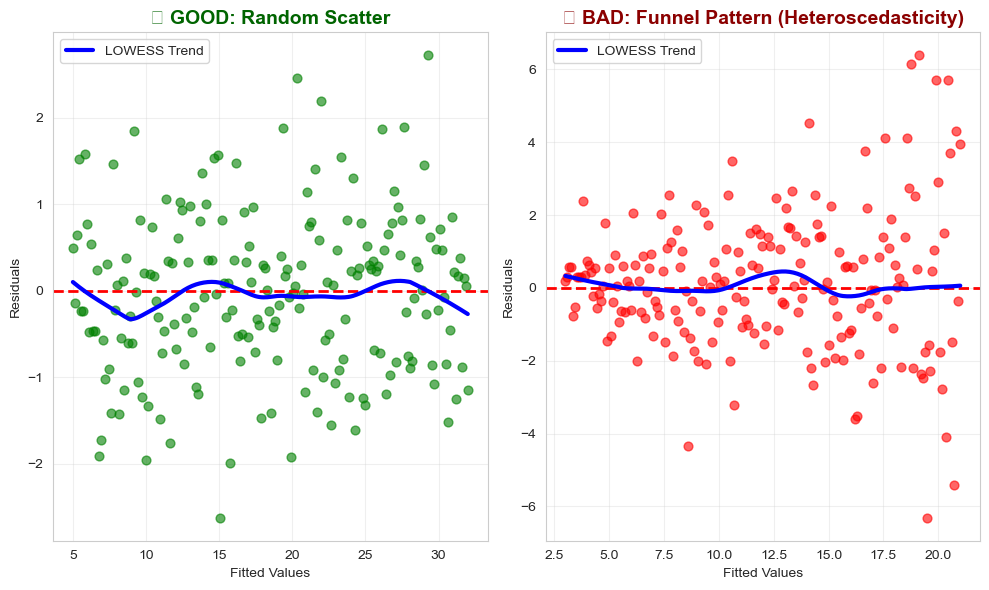

In [3]:
#==============================================================================
# VISUALIZATION: Residuals vs Fitted Patterns
#==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Helper function to add lowess line
def add_lowess_line(ax, x_vals, y_vals, color='blue'):
    lowess_line = lowess(y_vals, x_vals, frac=0.3)
    ax.plot(lowess_line[:, 0], lowess_line[:, 1], color=color, linewidth=3, label='LOWESS Trend')

# Plot 1: Good Model
ax1.scatter(fitted_good, residuals_good, alpha=0.6, s=40, color='green')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
add_lowess_line(ax1, fitted_good, residuals_good)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('✅ GOOD: Random Scatter', fontsize=14, fontweight='bold', color='darkgreen')
ax1.grid(True, alpha=0.3)
ax1.legend()


# Plot 2: Heteroscedasticity
ax2.scatter(fitted_hetero, residuals_hetero, alpha=0.6, s=40, color='red')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
add_lowess_line(ax2, fitted_hetero, residuals_hetero, 'blue')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('❌ BAD: Funnel Pattern (Heteroscedasticity)', fontsize=14, fontweight='bold', color='darkred')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

---

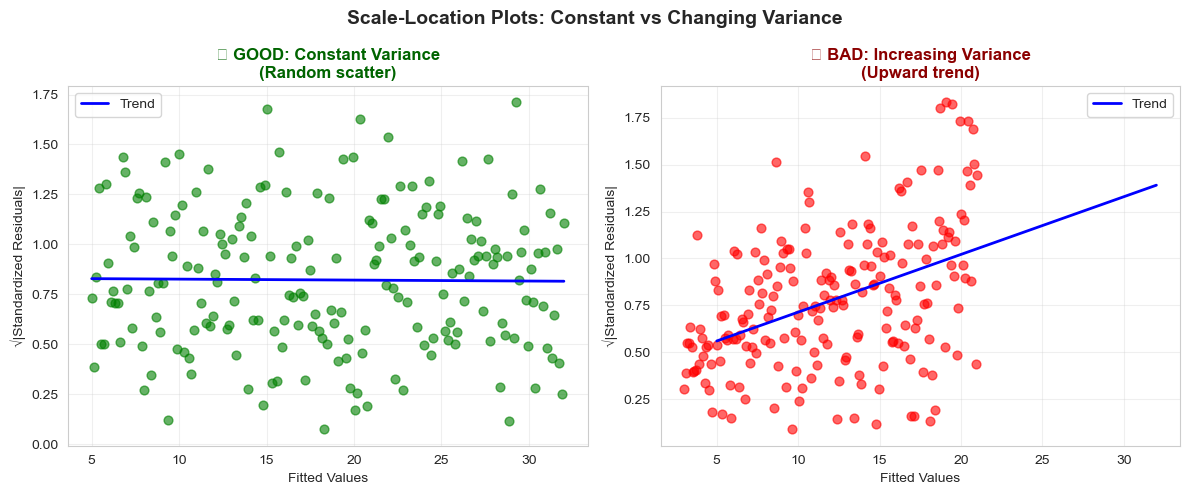

In [4]:
#==============================================================================
# SCALE-LOCATION PLOTS: Constant vs Changing Variance
#==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Good: Constant variance
standardized_good = residuals_good / np.std(residuals_good)
sqrt_abs_good = np.sqrt(np.abs(standardized_good))
axes[0].scatter(fitted_good, sqrt_abs_good, alpha=0.6, s=40, color='green')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('√|Standardized Residuals|')
axes[0].set_title('✅ GOOD: Constant Variance\n(Random scatter)', fontsize=12, fontweight='bold', color='darkgreen')
axes[0].grid(True, alpha=0.3)

# Bad: Heteroscedasticity
standardized_hetero = residuals_hetero / np.std(residuals_hetero)
sqrt_abs_hetero = np.sqrt(np.abs(standardized_hetero))
axes[1].scatter(fitted_hetero, sqrt_abs_hetero, alpha=0.6, s=40, color='red')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('√|Standardized Residuals|')
axes[1].set_title('❌ BAD: Increasing Variance\n(Upward trend)', fontsize=12, fontweight='bold', color='darkred')
axes[1].grid(True, alpha=0.3)

# Add trend lines
from numpy.polynomial.polynomial import Polynomial
p_good = Polynomial.fit(fitted_good, sqrt_abs_good, 1)
p_hetero = Polynomial.fit(fitted_hetero, sqrt_abs_hetero, 1)

x_trend = np.linspace(min(fitted_good), max(fitted_good), 100)
axes[0].plot(x_trend, p_good(x_trend), 'blue', linewidth=2, label='Trend')
axes[1].plot(x_trend, p_hetero(x_trend), 'blue', linewidth=2, label='Trend')

axes[0].legend()
axes[1].legend()

plt.suptitle('Scale-Location Plots: Constant vs Changing Variance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()